In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\chahat\Downloads\heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# EDA and Data Cleaning

In [107]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [108]:
df.shape

(918, 12)

In [109]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [111]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [112]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

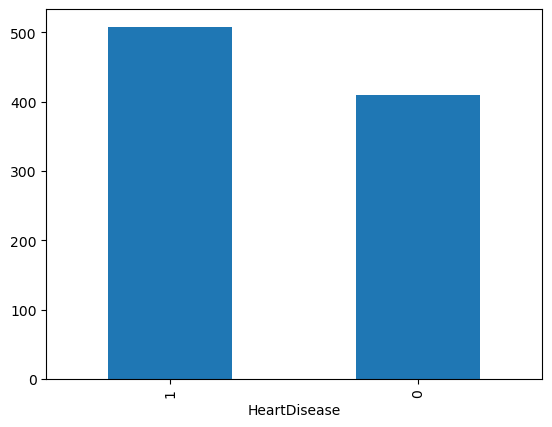

In [113]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [114]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [115]:
numeric = df.select_dtypes(include=['int','float']).columns
numeric

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

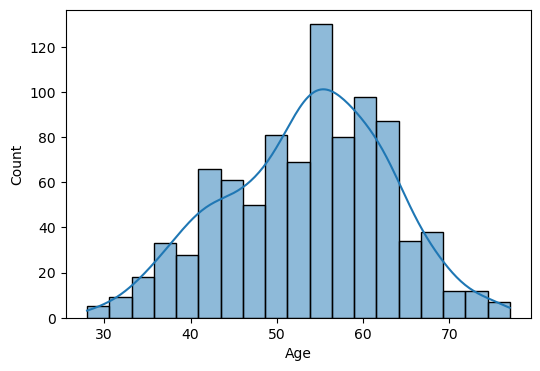

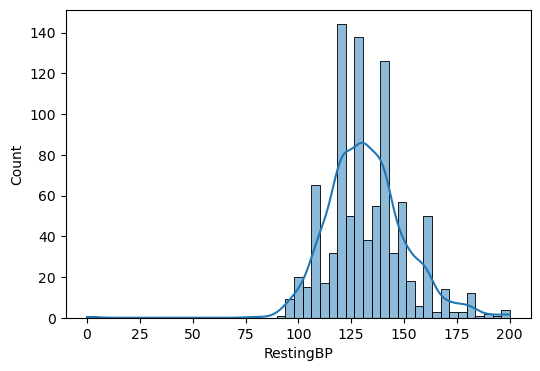

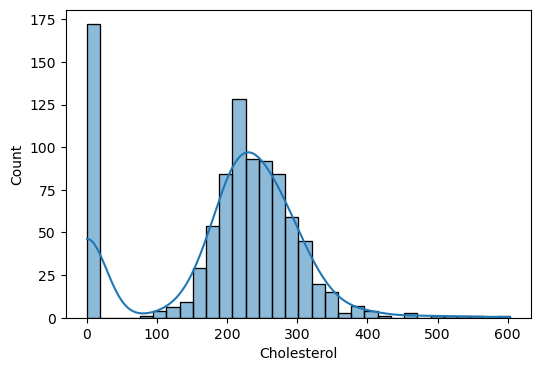

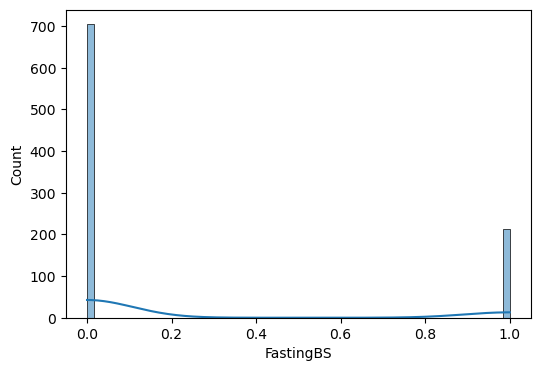

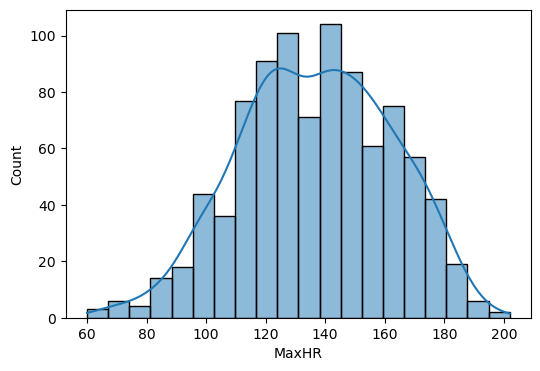

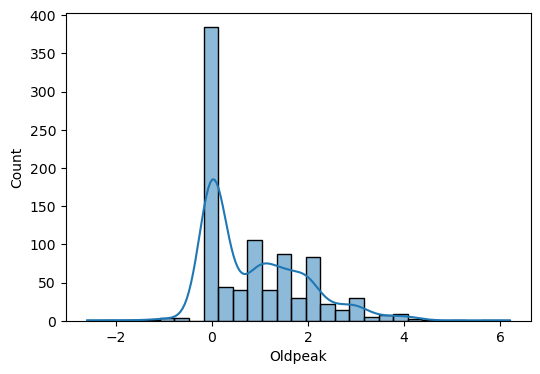

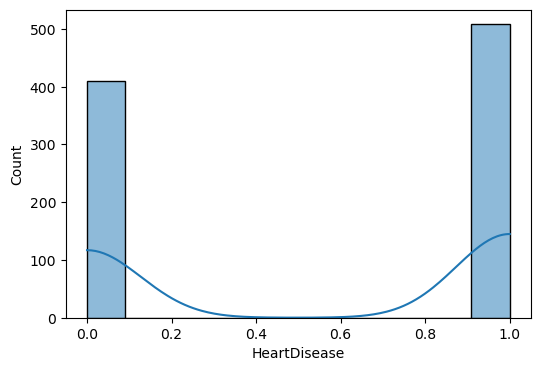

In [116]:
for i in numeric:
    plt.figure(figsize=(6,4))
    sns.histplot(x = df[i],kde=True)

In [117]:
ch_mean = df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [118]:
df['Cholesterol'] = df['Cholesterol'].replace({
    0:ch_mean
})

<Axes: xlabel='Cholesterol', ylabel='Count'>

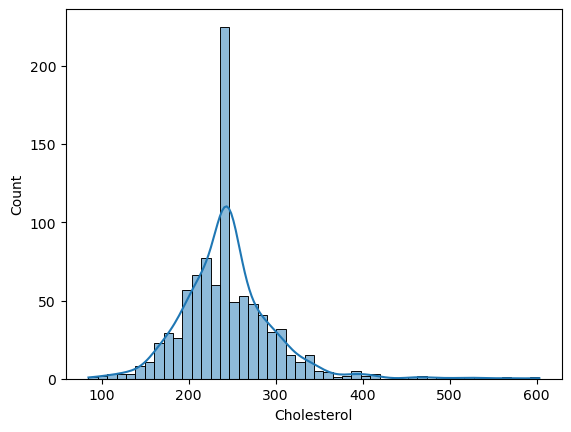

In [119]:
sns.histplot(x = df['Cholesterol'],kde=True)

In [120]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
185      1
98       1
92       1
113      1
164      1
Name: count, Length: 67, dtype: int64

In [121]:
rbp_mean = df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace({
    0:rbp_mean
})

<Axes: xlabel='RestingBP', ylabel='Count'>

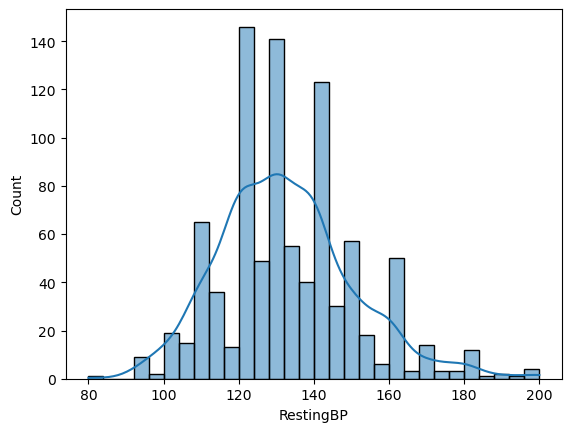

In [122]:
sns.histplot(x = df['RestingBP'],kde=True)

In [123]:
categorical = df.select_dtypes(include = ['object']).columns
categorical

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

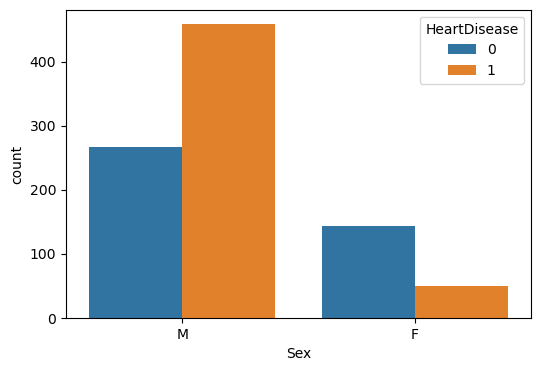

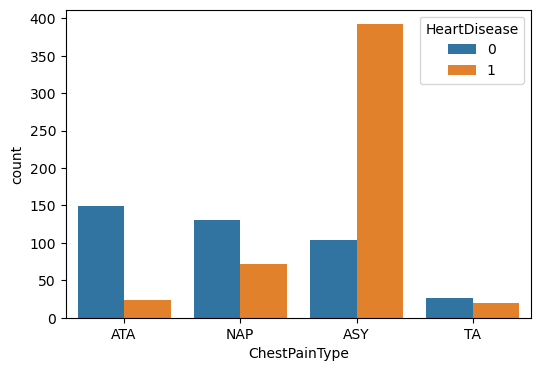

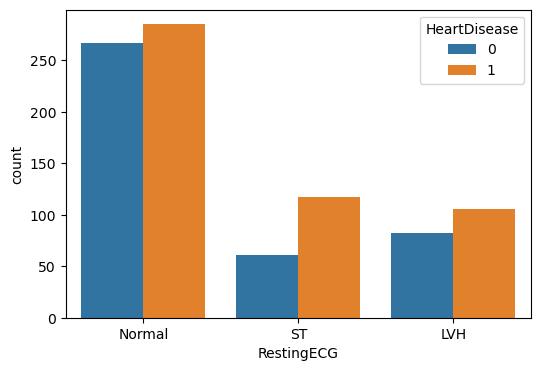

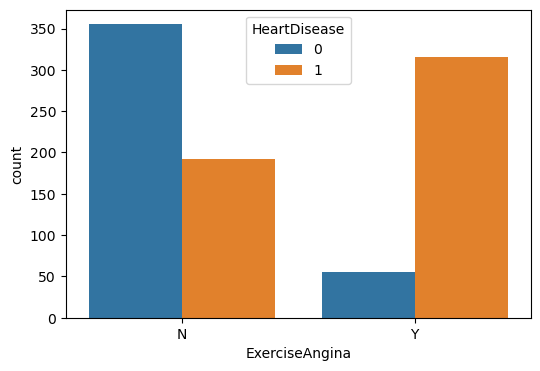

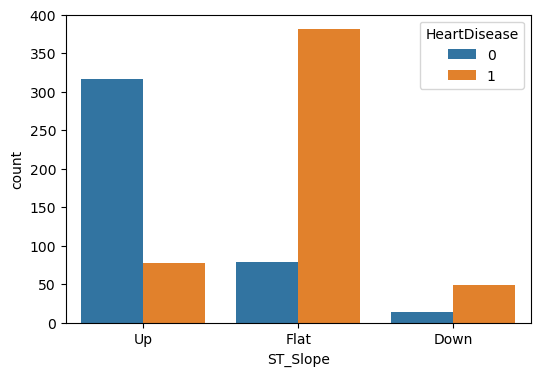

In [124]:
for i in categorical:
    plt.figure(figsize=(6,4))
    sns.countplot(x = df[i],hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

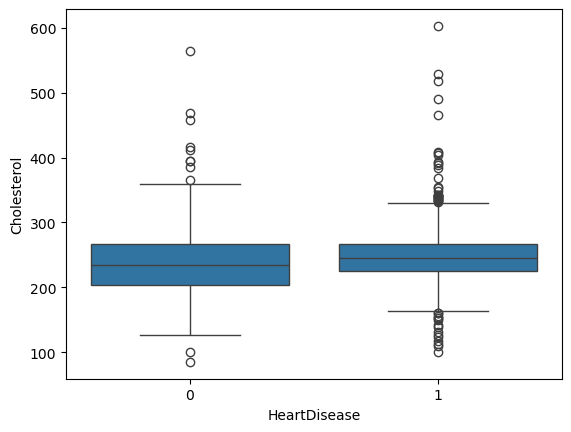

In [125]:
sns.boxplot(x = df['HeartDisease'],y = df['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

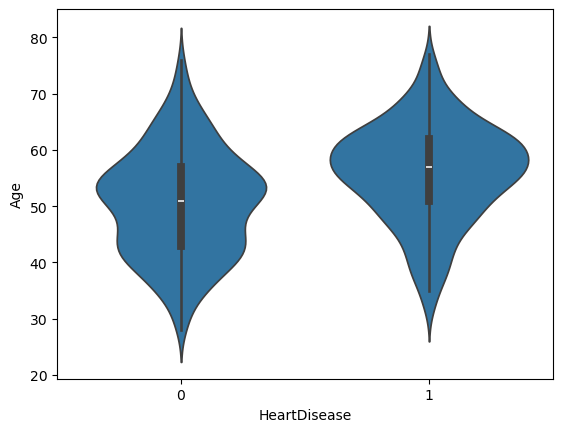

In [126]:
sns.violinplot(x = df['HeartDisease'],y = df['Age'])

<Axes: >

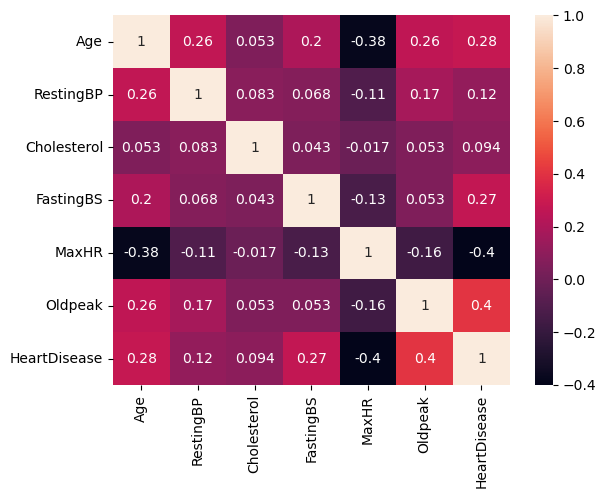

In [127]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

 # Data PreProcessing

In [128]:
categorical

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [129]:
for i in categorical:
    print(df[i].unique())

['M' 'F']
['ATA' 'NAP' 'ASY' 'TA']
['Normal' 'ST' 'LVH']
['N' 'Y']
['Up' 'Flat' 'Down']


In [130]:
df1 = pd.get_dummies(df,columns = ['ChestPainType','RestingECG','ST_Slope'],dtype=int)
df1.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,M,140.0,289.0,0,172,N,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,F,160.0,180.0,0,156,N,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,M,130.0,283.0,0,98,N,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,F,138.0,214.0,0,108,Y,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,M,150.0,195.0,0,122,N,0.0,0,0,0,1,0,0,1,0,0,0,1


In [131]:
df1['Sex'] = df1['Sex'].map({
    'M':0,
    'F':1
})

In [132]:
df1 = df1.rename(columns={
    'Sex':'is_female'
})

In [133]:
df1['ExerciseAngina'] = df1['ExerciseAngina'].map({
    'Y':1,
    'N':0
})

In [134]:
df1.head()

,Age,is_female,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,0,140.0,289.0,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,1,160.0,180.0,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,0,130.0,283.0,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,1,138.0,214.0,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,0,150.0,195.0,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1


In [135]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
z = ['Age','RestingBP','Cholesterol','MaxHR','MaxHR']
df1[z] = scaler.fit_transform(df1[z])

In [137]:
df1.head()

,Age,is_female,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0,0.414853,0.832529,0,1.382928,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,-0.478484,1,1.527192,-1.212922,0,0.754157,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,-1.751359,0,-0.141317,0.719935,0,-1.525138,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,-0.584556,1,0.303619,-0.574892,0,-1.132156,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,0.051881,0,0.971022,-0.931438,0,-0.581981,0,0.0,0,0,0,1,0,0,1,0,0,0,1
